# Ejercicio: Clustering con K-Means

En este notebook vas a implementar y experimentar con el algoritmo K-Means paso a paso.

**Objetivos:**
- Entender cómo funciona K-Means internamente
- Aplicarlo con `scikit-learn`
- Elegir el valor óptimo de `k` con el método del codo
- Visualizar e interpretar los clusters

## 1. Imports y configuración

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

plt.rcParams['figure.figsize'] = (8, 5)
np.random.seed(42)
print('Librerías cargadas correctamente ✓')

Librerías cargadas correctamente ✓


## 2. Generar datos de ejemplo

Vamos a crear un dataset sintético con grupos bien definidos.

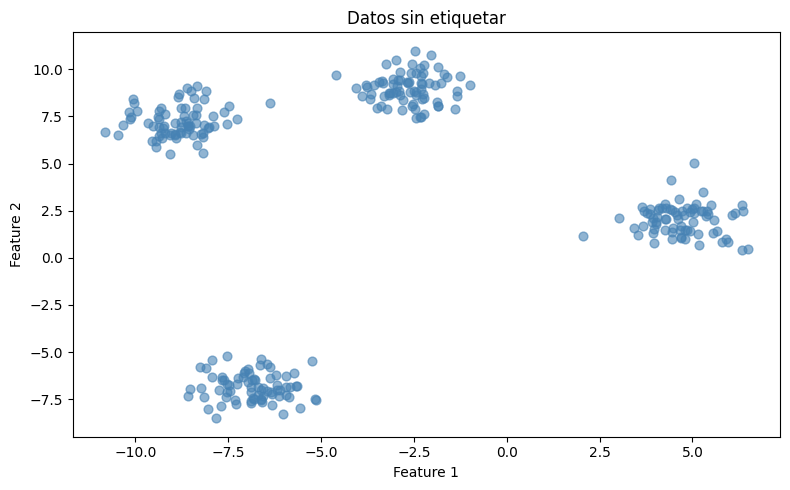

Shape del dataset: (300, 2)


In [2]:
X, y_true = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=0.8,
    random_state=42
)

plt.scatter(X[:, 0], X[:, 1], s=40, alpha=0.6, color='steelblue')
plt.title('Datos sin etiquetar')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.tight_layout()
plt.show()

print(f'Shape del dataset: {X.shape}')

## 3. Preprocesamiento

K-Means es sensible a la escala. Siempre normaliza antes de aplicarlo.

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Media antes de escalar: ', X.mean(axis=0).round(2))
print('Media después de escalar:', X_scaled.mean(axis=0).round(2))
print('Std después de escalar: ', X_scaled.std(axis=0).round(2))

Media antes de escalar:  [-3.4   2.85]
Media después de escalar: [0. 0.]
Std después de escalar:  [1. 1.]


## 4. Método del Codo (Elbow Method)

Probamos diferentes valores de `k` y graficamos la inercia (suma de distancias cuadradas al centroide más cercano).

**Tu tarea:** Observa la gráfica e identifica en qué valor de `k` la curva forma un "codo".

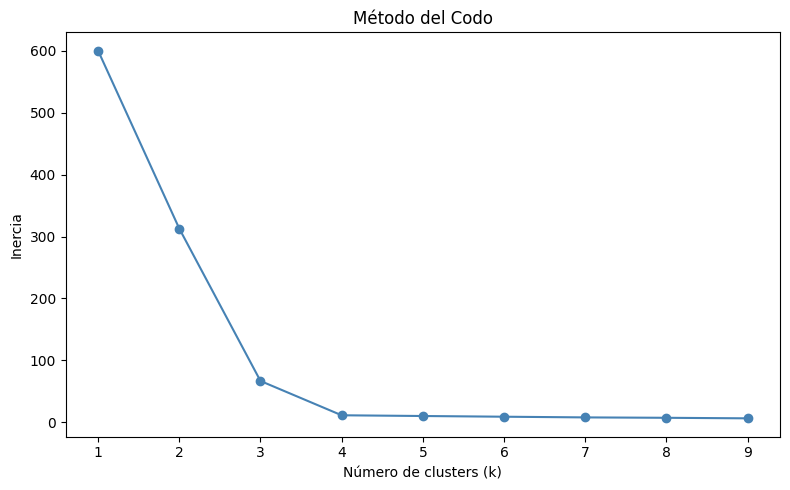

k óptimo elegido: None


In [4]:
inercias = []
rango_k = range(1, 10)

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X_scaled)
    inercias.append(km.inertia_)

plt.plot(rango_k, inercias, 'o-', color='steelblue')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo')
plt.xticks(rango_k)
plt.tight_layout()
plt.show()

# TODO: ¿En qué valor de k ves el codo?
k_optimo = None  # <- Escribe tu respuesta aquí
print(f'k óptimo elegido: {k_optimo}')

## 5. Puntuación de Silueta

El **Silhouette Score** mide qué tan bien separados están los clusters. Va de -1 a 1; valores cercanos a 1 son mejores.

k=2  Silhouette Score: 0.5700
k=3  Silhouette Score: 0.7642
k=4  Silhouette Score: 0.8386
k=5  Silhouette Score: 0.7089
k=6  Silhouette Score: 0.5767
k=7  Silhouette Score: 0.4564
k=8  Silhouette Score: 0.4650
k=9  Silhouette Score: 0.3510


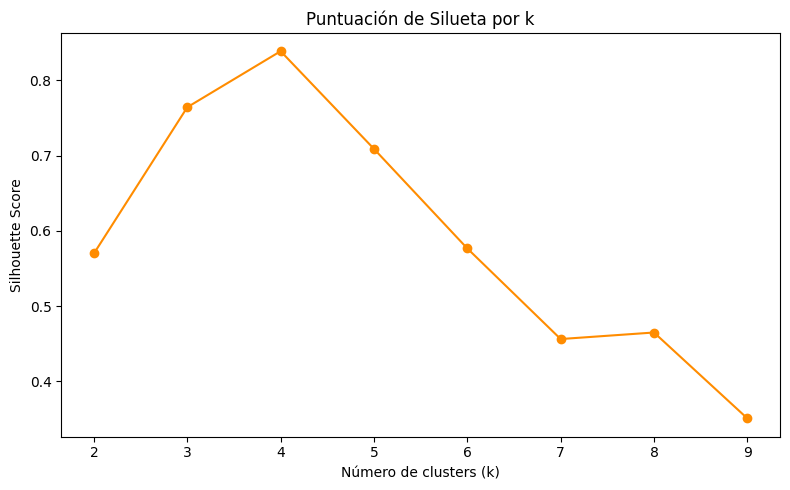

In [5]:
siluetas = []

for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    siluetas.append(score)
    print(f'k={k}  Silhouette Score: {score:.4f}')

plt.plot(range(2, 10), siluetas, 'o-', color='darkorange')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Puntuación de Silueta por k')
plt.xticks(range(2, 10))
plt.tight_layout()
plt.show()

## 6. Entrenar el modelo final

Usa el `k` que encontraste en los pasos anteriores.

In [6]:
# TODO: Cambia k por el valor óptimo que encontraste
k = 4

kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
etiquetas = kmeans.fit_predict(X_scaled)
centroides = kmeans.cluster_centers_

print(f'Modelo entrenado con k={k}')
print(f'Inercia final: {kmeans.inertia_:.2f}')
print(f'Iteraciones hasta converger: {kmeans.n_iter_}')

Modelo entrenado con k=4
Inercia final: 11.32
Iteraciones hasta converger: 2


## 7. Visualizar los clusters

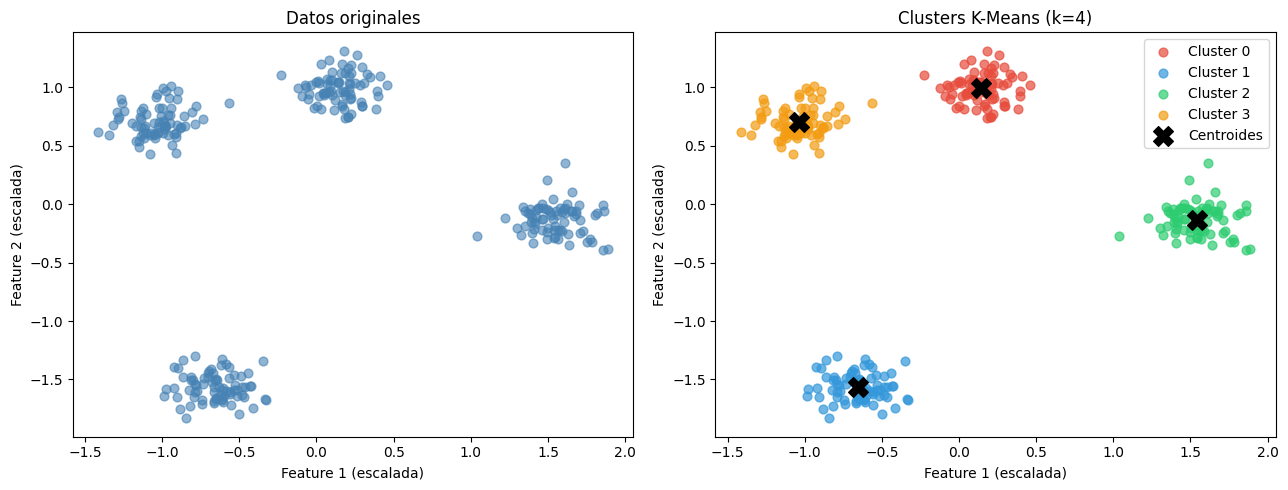

In [7]:
colores = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Datos originales (sin etiquetas)
axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], s=40, alpha=0.6, color='steelblue')
axes[0].set_title('Datos originales')
axes[0].set_xlabel('Feature 1 (escalada)')
axes[0].set_ylabel('Feature 2 (escalada)')

# Clusters predichos
for i in range(k):
    mask = etiquetas == i
    axes[1].scatter(X_scaled[mask, 0], X_scaled[mask, 1],
                    s=40, alpha=0.7, color=colores[i], label=f'Cluster {i}')

axes[1].scatter(centroides[:, 0], centroides[:, 1],
                s=200, c='black', marker='X', zorder=5, label='Centroides')
axes[1].set_title(f'Clusters K-Means (k={k})')
axes[1].set_xlabel('Feature 1 (escalada)')
axes[1].set_ylabel('Feature 2 (escalada)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Análisis de los clusters

Cuántos puntos hay en cada cluster y cuáles son sus centroides.

In [8]:
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])
df['Cluster'] = etiquetas

print('Distribución de puntos por cluster:')
print(df['Cluster'].value_counts().sort_index())
print()
print('Estadísticas por cluster (datos originales):')
print(df.groupby('Cluster').mean().round(2))

Distribución de puntos por cluster:
Cluster
0    75
1    75
2    75
3    75
Name: count, dtype: int64

Estadísticas por cluster (datos originales):
         Feature_1  Feature_2
Cluster                      
0            -2.64       8.99
1            -6.84      -6.84
2             4.70       2.03
3            -8.83       7.22


## 9. Desafío: Dataset real

Ahora aplica K-Means al dataset `Iris` usando solo las columnas numéricas.

**Instrucciones:**
1. Carga el dataset
2. Escala las features
3. Usa el método del codo para elegir `k`
4. Entrena el modelo y visualiza los clusters
5. Compara los clusters con las clases reales de la flor

In [9]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
df_iris = iris.frame

print(df_iris.head())
print()
print('Clases reales:', iris.target_names.tolist())

# TODO: Tu código aquí
# 1. Selecciona solo las columnas numéricas
# X_iris = ...

# 2. Escala los datos
# X_iris_scaled = ...

# 3. Aplica el método del codo

# 4. Entrena con el k elegido

# 5. Visualiza (puedes usar las primeras 2 features para graficar)

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

Clases reales: ['setosa', 'versicolor', 'virginica']
